In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import pickle

from src.helper_functions.reconstruct_parameters import reconstruct_gamma, compute_tau

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colours = [(208/255, 28/255, 139/255),
           (241/255, 182/255, 218/255),
           (184/255, 225/255, 134/255),
           (77/255, 172/255, 38/255)]

colours10 = [(166/255, 206/255, 227/255),
             (31/255, 120/255, 180/255),
             (178/255, 223/255, 138/255),
             (51/255, 160/255, 44/255),
             (251/255, 154/255, 153/255),
             (227/255, 26/255, 28/255),
             (253/255, 191/255, 111/255),
             (255/255, 127/255, 0/255),
             (202/255, 178/255, 214/255),
             (106/255, 61/255, 154/255)]

In [3]:
def load_pickled_file(filepath):
    with open(filepath, 'rb') as file:
        data = pickle.load(file)
    return data

base_path = 'simulations/simulation_2/output'

In [4]:
layer_groups = {}

phi_w_list = {}
phi_z_list = {}
alpha_rho_list = {}
beta_rho_list = {}

ELBO_full_list = {}

missing_idx = []

for i in range(300):
    try:
        ## SIMULATION PARAMETERS
        # layers
        data = np.load(f'{base_path}/layer_groups/layer_groups_{i}.npy')
        # layer_groups.append(data)
        layer_groups[i] = data
    except FileNotFoundError:
        pass 
    try:
        ## PARAMETERS
        # phi_w
        data = load_pickled_file(f'{base_path}/phi_w/phi_w_{i}.pkl')
        # phi_w_list.append(data)
        phi_w_list[i] = data
    except FileNotFoundError:
        print(f"Missing phi_w {i}")
        missing_idx.append(i)
    try:
        # phi_u
        data = load_pickled_file(f'{base_path}/phi_z/phi_z_{i}.pkl')
        # phi_z_list.append(data)
        phi_z_list[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # alpha_rho
        data = load_pickled_file(f'{base_path}/alpha_rho/alpha_rho_{i}.pkl')
        # alpha_rho_list.append(data)
        alpha_rho_list[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # beta_rho
        data = load_pickled_file(f'{base_path}/beta_rho/beta_rho_{i}.pkl')
        # beta_rho_list.append(data)
        beta_rho_list[i] = data
    except FileNotFoundError:
        pass
    try:
        ## ELBO
        # ELBO_full
        data = load_pickled_file(f'{base_path}/ELBO/ELBO_full_{i}.pkl')
        # ELBO_full_list.append(data)
        ELBO_full_list[i] = data
    except FileNotFoundError:
        pass

Missing phi_w 2
Missing phi_w 42
Missing phi_w 52


In [5]:
def load_pickled_file(filepath):
    with open(filepath, 'rb') as file:
        data = pickle.load(file)
    return data

base_path = 'simulations/simulation_2/output_uni'

In [6]:
layer_groups_uni = {}

phi_w_list_uni = {}
phi_z_list_uni = {}
alpha_rho_list_uni = {}
beta_rho_list_uni = {}

ELBO_full_list_uni = {}

missing_idx_uni = []

for i in range(300):
    try:
        ## SIMULATION PARAMETERS
        # layers
        data = np.load(f'{base_path}/layer_groups/layer_groups_{i}.npy')
        # layer_groups.append(data)
        layer_groups_uni[i] = data
    except FileNotFoundError:
        pass 
    try:
        ## PARAMETERS
        # phi_w
        data = load_pickled_file(f'{base_path}/phi_w/phi_w_{i}.pkl')
        # phi_w_list.append(data)
        phi_w_list_uni[i] = data
    except FileNotFoundError:
        print(f"Missing phi_w {i}")
        missing_idx.append(i)
    try:
        # phi_u
        data = load_pickled_file(f'{base_path}/phi_z/phi_z_{i}.pkl')
        # phi_z_list.append(data)
        phi_z_list_uni[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # alpha_rho
        data = load_pickled_file(f'{base_path}/alpha_rho/alpha_rho_{i}.pkl')
        # alpha_rho_list.append(data)
        alpha_rho_list_uni[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # beta_rho
        data = load_pickled_file(f'{base_path}/beta_rho/beta_rho_{i}.pkl')
        # beta_rho_list.append(data)
        beta_rho_list_uni[i] = data
    except FileNotFoundError:
        pass
    try:
        ## ELBO
        # ELBO_full
        data = load_pickled_file(f'{base_path}/ELBO/ELBO_full_{i}.pkl')
        # ELBO_full_list.append(data)
        ELBO_full_list_uni[i] = data
    except FileNotFoundError:
        pass

In [7]:
global_groups = np.concatenate(
    (np.repeat(0, 200),
     np.repeat(1, 200),
     np.repeat(2, 100))
)
num_sims = 6
ARI_w = []
for sim in range(num_sims):
    ARI_sim = []
    for i in range(int(sim * 50), int((sim + 1) * 50)):
        if i not in missing_idx:
            ARI_i = normalized_mutual_info_score(phi_w_list[i].argmax(axis=1), global_groups)
            ARI_i = np.array(ARI_i)
            ARI_sim.append(ARI_i)
    ARI_w.append(np.stack(ARI_sim))
    
ARI_w_uni = []
for sim in range(num_sims):
    ARI_sim_uni = []
    for i in range(int(sim * 50), int((sim + 1) * 50)):
        if i not in missing_idx:
            ARI_i_uni = normalized_mutual_info_score(phi_w_list_uni[i].argmax(axis=1), global_groups)
            ARI_i_uni = np.array(ARI_i_uni)
            ARI_sim_uni.append(ARI_i_uni)
    ARI_w_uni.append(np.stack(ARI_sim_uni))

In [8]:
num_layers = 10
ARI_z = []
for sim in range(num_sims):
    ARI_sim = []
    for l in range(num_layers):
        ARI_sim_layer = []
        for i in range(int(sim * 50), int((sim + 1) * 50)):
            if i not in missing_idx:
                ARI_sim_layer_i = normalized_mutual_info_score(phi_z_list[i].argmax(axis=2)[l], layer_groups[i][l])
                ARI_sim_layer.append(np.array(ARI_sim_layer_i))
        ARI_sim.append(np.stack(ARI_sim_layer))
    ARI_z.append(ARI_sim)

ARI_z_across = [np.array(ARI_z[i]).flatten() for i in range(num_sims)]

ARI_z_uni = []
for sim in range(num_sims):
    ARI_sim_uni = []
    for l in range(num_layers):
        ARI_sim_layer_uni = []
        for i in range(int(sim * 50), int((sim + 1) * 50)):
            if i not in missing_idx:
                ARI_sim_layer_i_uni = normalized_mutual_info_score(phi_z_list_uni[i].argmax(axis=2)[l], layer_groups_uni[i][l])
                ARI_sim_layer_uni.append(np.array(ARI_sim_layer_i_uni))
        ARI_sim_uni.append(np.stack(ARI_sim_layer_uni))
    ARI_z_uni.append(ARI_sim_uni)

ARI_z_across_uni = [np.array(ARI_z_uni[i]).flatten() for i in range(num_sims)]

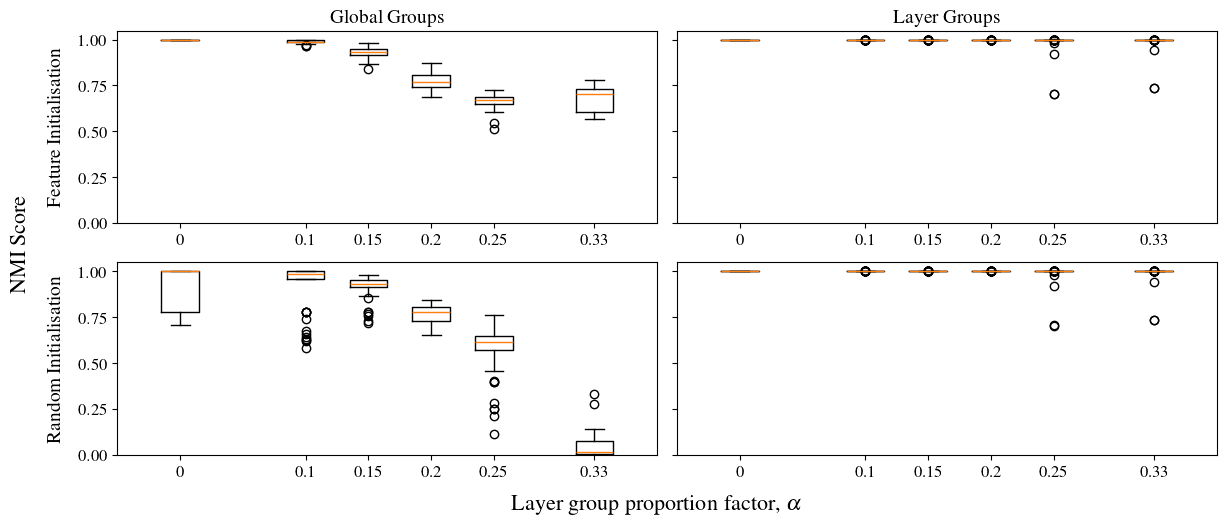

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots (side-by-side)
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharey=True)

# Convert labels to numeric values for tick positions
tick_positions = [0, 0.1, 0.15, 0.2, 0.25, 0.33]
labels = ['0', '0.1', '0.15', '0.2', '0.25', '0.33']

# Adjust box width
box_width = 0.03  # Reduce this value to make boxes narrower

# First row
axes[0,0].boxplot([ARI_w[i] for i in range(num_sims)], positions=tick_positions, widths=box_width)
axes[0,0].set_ylim(0, 1.05)
axes[0,0].set_xlim(-0.05, 0.38)  # Set x-axis limits with some padding
axes[0,0].set_xticks(tick_positions)
axes[0,0].set_xticklabels(labels)
axes[0,0].set_ylabel('Feature Initialisation', labelpad=10)
axes[0,0].set_title('Global Groups')

axes[0,1].boxplot([ARI_z_across[i] for i in range(num_sims)], positions=tick_positions, widths=box_width)
axes[0,1].set_ylim(0, 1.05)
axes[0,1].set_xlim(-0.05, 0.38)  # Set x-axis limits with some padding
axes[0,1].set_xticks(tick_positions)
axes[0,1].set_xticklabels(labels)
axes[0,1].set_title('Layer Groups')

# Second row
axes[1,0].boxplot([ARI_w_uni[i] for i in range(num_sims)], positions=tick_positions, widths=box_width)
axes[1,0].set_ylim(0, 1.05)
axes[1,0].set_xlim(-0.05, 0.38)  # Set x-axis limits with some padding
axes[1,0].set_xticks(tick_positions)
axes[1,0].set_xticklabels(labels)
axes[1,0].set_ylabel('Random Initialisation', labelpad=10)

axes[1,1].boxplot([ARI_z_across_uni[i] for i in range(num_sims)], positions=tick_positions, widths=box_width)
axes[1,1].set_ylim(0, 1.05)
axes[1,1].set_xlim(-0.05, 0.38)  # Set x-axis limits with some padding
axes[1,1].set_xticks(tick_positions)
axes[1,1].set_xticklabels(labels)

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.label.set_size(14)  # x-label font size
    ax.yaxis.label.set_size(14)  # y-label font size
    ax.title.set_size(14)  # title font size

# Add row labels
fig.text(-0.01, 0.5, "NMI Score", va='center', ha='center', rotation=90, fontsize=16, fontweight='bold')
fig.text(0.52, -0.02, r"Layer group proportion factor, $\alpha$", va='center', ha='center', fontsize=16, fontweight='bold')

# Adjust layout and show the figure
plt.tight_layout()
plt.savefig("simulations/simulation_2/plots/NMI_boxplots_spaced.pdf", dpi=300, bbox_inches="tight")
plt.show()